# Task 2: PPO experiments

Training and evaluation are implemented in `task2_ppo/`.
This notebook displays saved metrics, figures, and qualitative examples.

GPU runs are disabled by default. Run all cells on CPU to inspect
the saved results. See the repository README for reproduction
instructions and experimental limitations.

In [1]:
from google.colab import drive
from pathlib import Path
import os

drive.mount("/content/drive")
repo = Path("/content/drive/MyDrive/ATML/PA2/ATML-PA2-LLM-PostTraining")
assert repo.is_dir(), f"Repository not found: {repo}"
os.chdir(repo)
print("Current folder:", Path.cwd())


Mounted at /content/drive
Current folder: /content/drive/MyDrive/ATML/PA2/ATML-PA2-LLM-PostTraining


In [2]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-r', 'requirements.txt'], returncode=0)

In [3]:
subprocess.run([sys.executable, "-m", "py_compile",
                *map(str, Path("task2_ppo").glob("*.py"))], check=True)
subprocess.run([sys.executable, "-m", "task2_ppo.validate_objective"], check=True)
print(Path("configs/ppo.yaml").read_text())


base_config: configs/base.yaml

# Short continuation from the supplied midpoint.
updates: 20
fork_updates: 8
prompts_per_update: 1
ppo_epochs: 2

policy_learning_rate: 3.0e-6
value_lora_learning_rate: 1.0e-4
value_head_learning_rate: 3.0e-4
value_train_mode: lora_head

clip_epsilon: 0.20
clip_values: [0.05, 0.20, 0.50]
kl_beta: 0.10
kl_values: [0.0, 0.10, 0.20]

gamma: 1.0
gae_lambda: 0.95
value_coef: 0.50
missing_eos_penalty: 1.0

max_prompt_length: 256
# Instructor midpoint training used this operational budget. The supplied midpoint has a
# documented long-tail termination limitation; use the larger cap for frozen evaluation.
max_response_length: 512
eval_max_response_length: 768
reward_max_length: 1280
max_grad_norm: 1.0

output: outputs/task2_ppo/standard
results_dir: results/task2_ppo
cached_rollouts: cached/ppo_rollout.pt



In [4]:
# GPU reproduction: standard continuation and cached clipping diagnostic.
RUN_STANDARD_GPU = False

if RUN_STANDARD_GPU:
    import torch
    assert torch.cuda.is_available(), "This cell requires a GPU."
    commands = [
        ["task2_ppo.analyze_clipping", "--config", "configs/ppo.yaml", "--stage", "cache"],
        ["task2_ppo.continue_train", "--config", "configs/ppo.yaml", "--run-name", "standard",
         "--output", "outputs/task2_ppo/standard"],
        ["task2_ppo.evaluate", "--config", "configs/ppo.yaml",
         "--adapter", "outputs/task2_ppo/standard", "--name", "standard"],
    ]
    for args in commands:
        subprocess.run([sys.executable, "-u", "-m", *args], check=True)
else:
    print("GPU standard run disabled; inspecting saved results.")


GPU standard run disabled; inspecting saved results.


In [5]:
# GPU reproduction: six 8-update forks and their held-out evaluations.
RUN_ABLATIONS_GPU = False

if RUN_ABLATIONS_GPU:
    import torch
    assert torch.cuda.is_available(), "This cell requires a GPU."
    for stage in ["train", "evaluate"]:
        for module in ["task2_ppo.analyze_clipping", "task2_ppo.ablate_kl"]:
            subprocess.run([sys.executable, "-u", "-m", module,
                            "--config", "configs/ppo.yaml", "--stage", stage], check=True)
else:
    print("GPU ablations disabled; inspecting saved results.")


GPU ablations disabled; inspecting saved results.


In [6]:
import pandas as pd
from IPython.display import display, Image

subprocess.run([sys.executable, "-m", "task2_ppo.plot_results"], check=True)
results = Path("results/task2_ppo")
display(pd.read_csv(results / "ppo_comparison.csv"))
display(pd.read_csv(results / "cached_clipping_comparison.csv"))


,name,num_eval_prompts,reward_model_score_mean,effective_reward_mean,response_length_mean,response_length_std,generation_cap_rate,sampled_kl_token_mean,entropy_token_mean,updates,clip_epsilon,kl_beta,wall_seconds,peak_vram_gib,skipped_policy_steps,skipped_value_steps,policy_skip_fraction,critic_skip_fraction,mean_online_clip_fraction
0,standard,200,1.460134,1.330134,317.865,265.926582,0.130,0.000005,1.020307,20,0.20,0.1,231.595195,7.694422,0,2,0.0,0.050,0.0
1,clip_0p05,200,1.437428,1.322428,311.385,261.232744,0.115,-0.000006,1.028949,8,0.05,0.1,49.008627,7.504755,0,2,0.0,0.125,0.0
2,clip_0p20,200,1.502923,1.392923,312.415,260.134778,0.110,-0.000012,1.026841,8,0.20,0.1,47.140983,7.504755,0,2,0.0,0.125,0.0
3,clip_0p50,200,1.526174,1.426174,310.725,257.473764,0.100,0.000001,1.017521,8,0.50,0.1,46.798148,7.504755,0,2,0.0,0.125,0.0
4,kl_0p00,200,1.538524,1.433524,309.925,256.858832,0.105,-0.000013,1.020691,8,0.20,0.0,47.861402,7.504755,0,2,0.0,0.125,0.0
5,kl_0p10,200,1.550810,1.470810,303.665,252.176630,0.080,0.000011,1.019469,8,0.20,0.1,46.799084,7.504755,0,2,0.0,0.125,0.0
6,kl_0p20,200,1.551161,1.451161,314.025,261.490333,0.100,0.000010,1.014795,8,0.20,0.2,46.873208,7.504755,0,2,0.0,0.125,0.0


,epsilon,clipped_surrogate,clip_fraction,affected_token_fraction,surrogate_changed_token_fraction
0,0.05,-0.005345,0.108237,0.108237,0.052870
1,0.20,-0.003955,0.008282,0.008282,0.004538
2,0.50,-0.003295,0.005559,0.005559,0.003290


In [7]:
import json

def read_rows(name, stage):
    path = results / f"{name}_{stage}.jsonl"
    return {row["row_index"]: row
            for line in path.read_text().splitlines() if line.strip()
            for row in [json.loads(line)]}

examples = []
for row_index, comparison in [(49, "clip_0p05"), (147, "kl_0p10")]:
    example = {"row_index": row_index, "conditions": {}}
    for name in ["standard", comparison]:
        generation = read_rows(name, "generations")[row_index]
        reward = read_rows(name, "rewards")[row_index]
        example["conditions"][name] = {
            **generation, "reward": reward["reward"],
            "effective_reward": reward["effective_reward"],
        }
    examples.append(example)
    print(f"\n--- Row {row_index} ---")
    print(example["conditions"]["standard"]["prompt_messages"][0]["content"])
    for name, row in example["conditions"].items():
        print(f"\n{name}: reward={row['reward']:.4f}")
        print(row["response"])

(results / "qualitative_examples.json").write_text(
    json.dumps(examples, indent=2, ensure_ascii=False))



--- Row 49 ---
Given the task definition and input, reply with output. Given a text, write a compressed version of it in a single sentence.

This little museum celebrates the ingenuity and courage of those who sought to escape to the West, and commemorates those who died trying to do so. Exhibits include the shopping cart in which a mother smuggled her infant son across the border.


standard: reward=2.5801
A museum honors those who risked their lives to escape to the west, featuring exhibits like a shopping cart used for smuggling an infant across borders.

clip_0p05: reward=1.9717
A museum honors those escaping to the west through ingenius and courageous efforts, recalling their sacrifices through exhibits like a baby smuggler's shopping cart.

--- Row 147 ---
Given the sentence "Five young lady getting ready to run the 100m dash." is it true that "A group of women prepare to race."?
Let's solve step-by-step:

standard: reward=2.1328
Step 1: Analyze the given sentence
The sentence s

19489

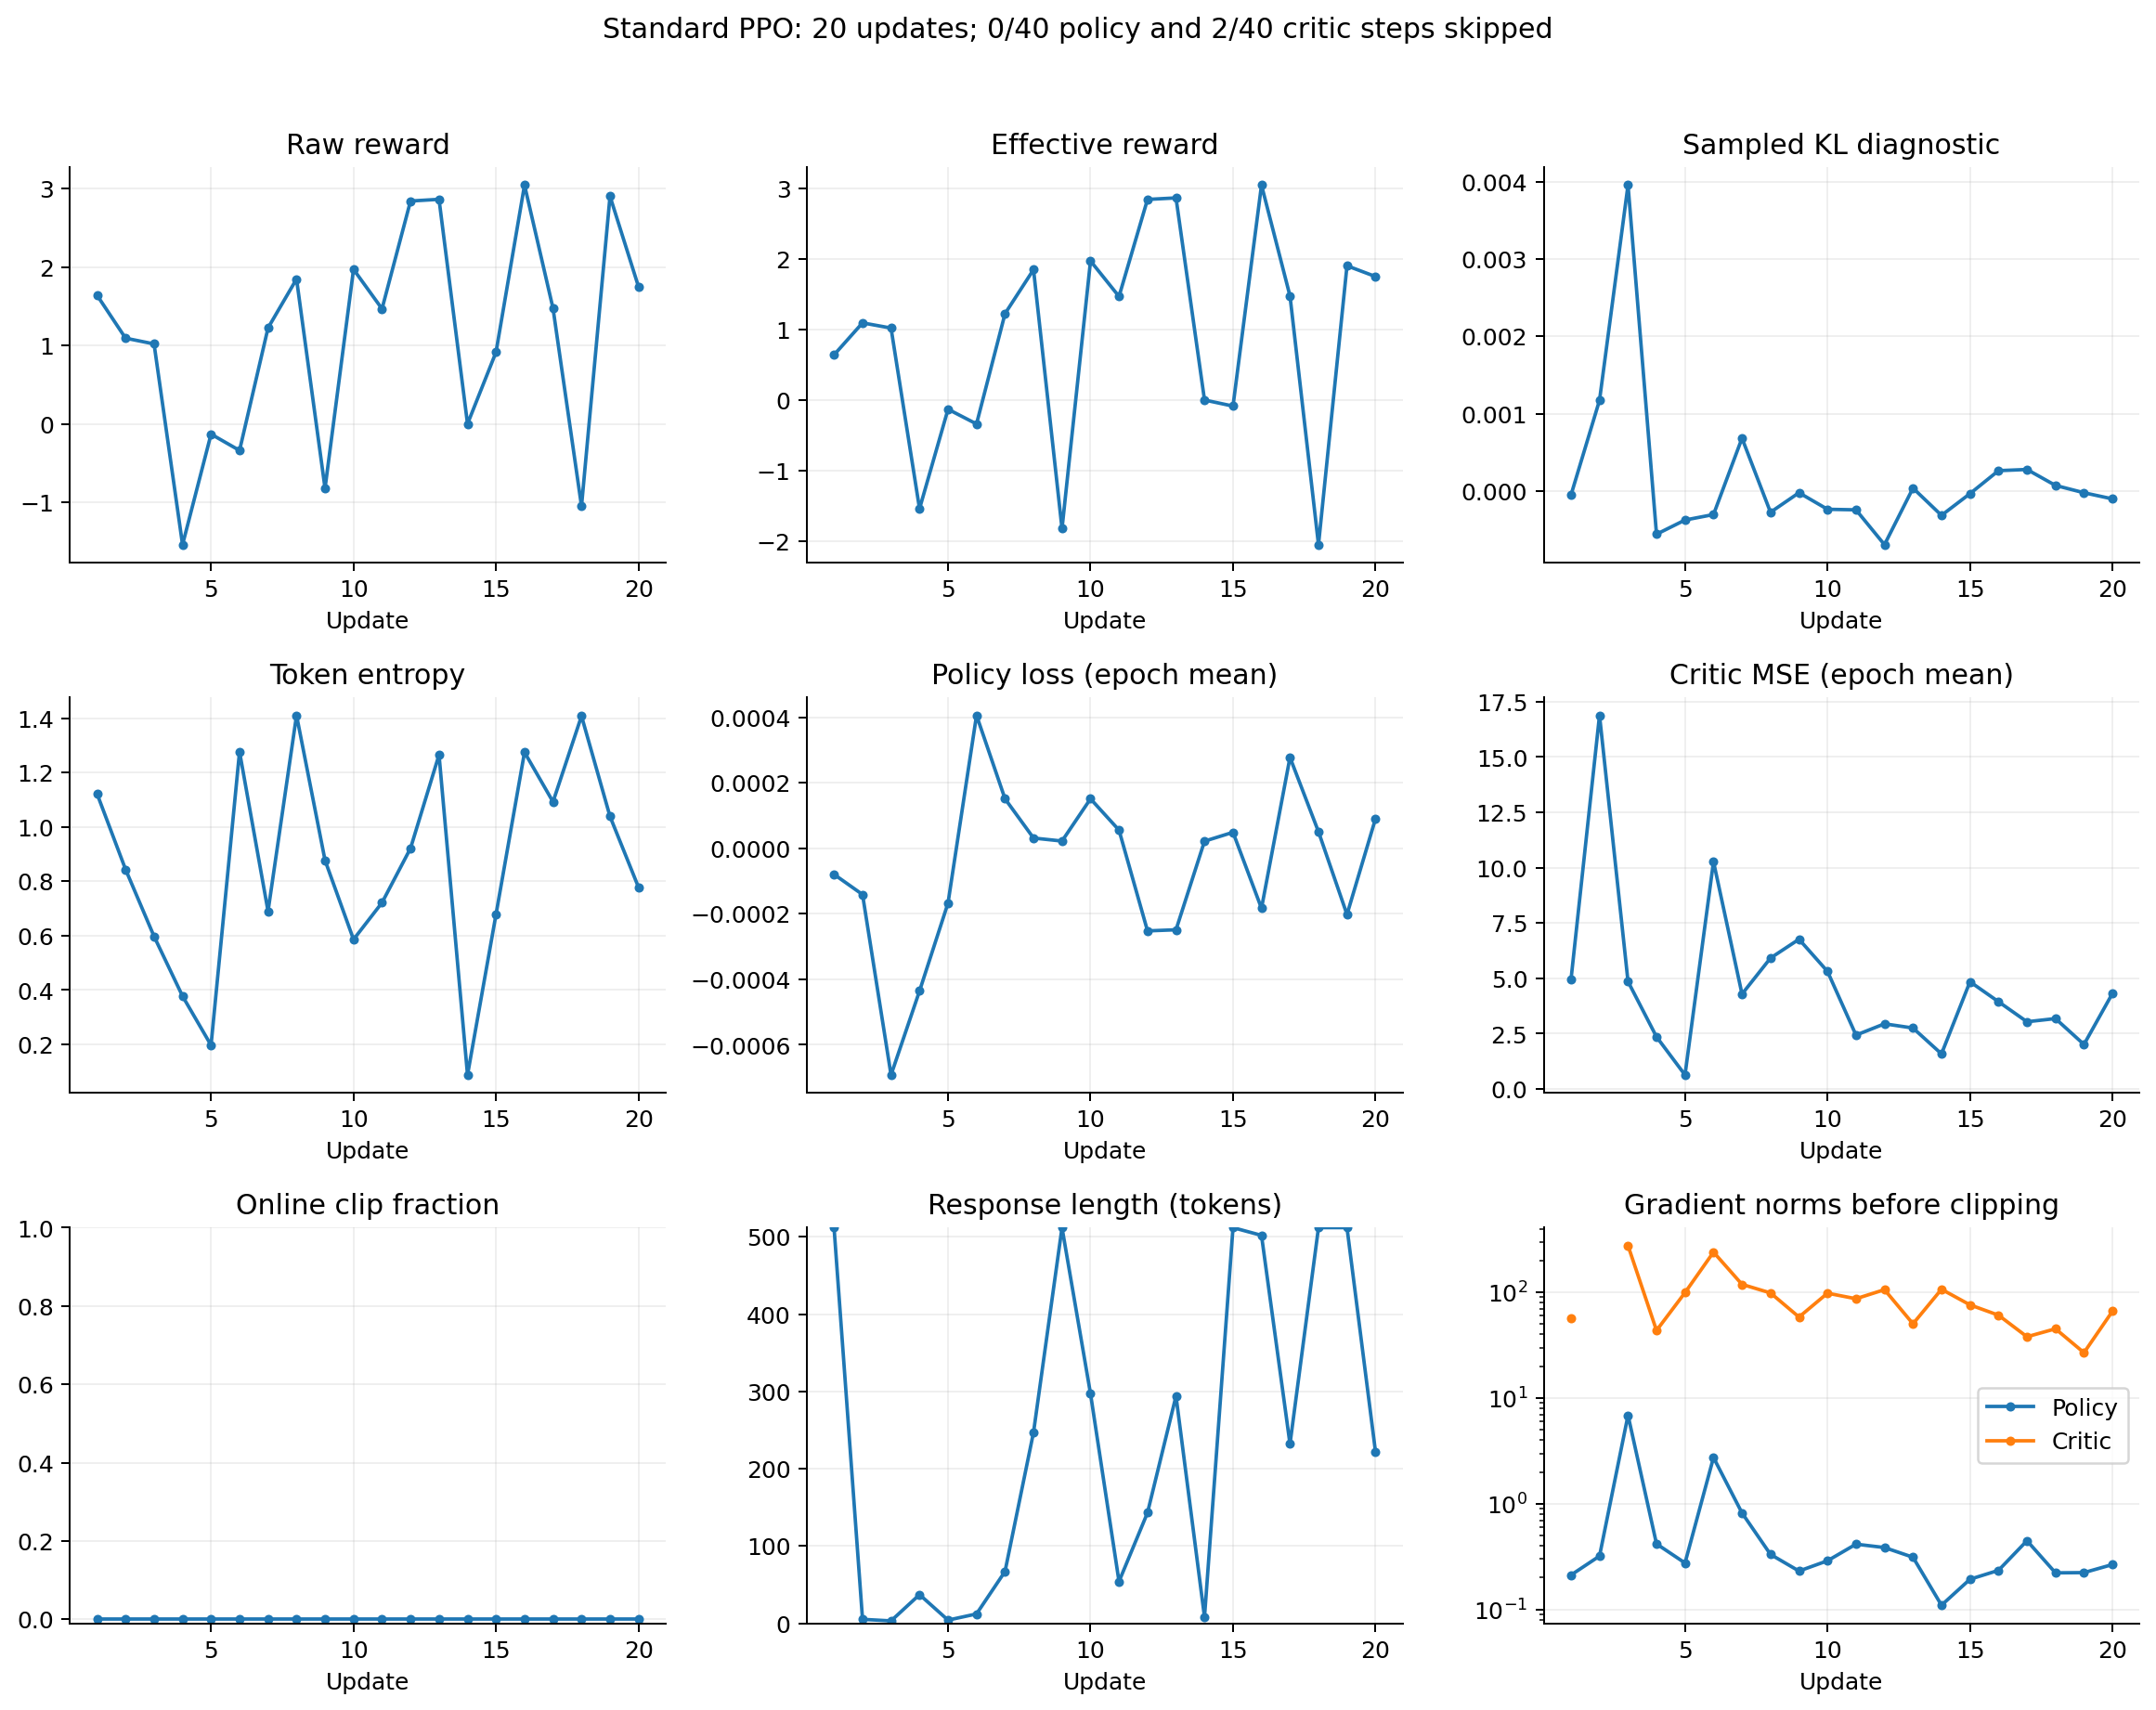

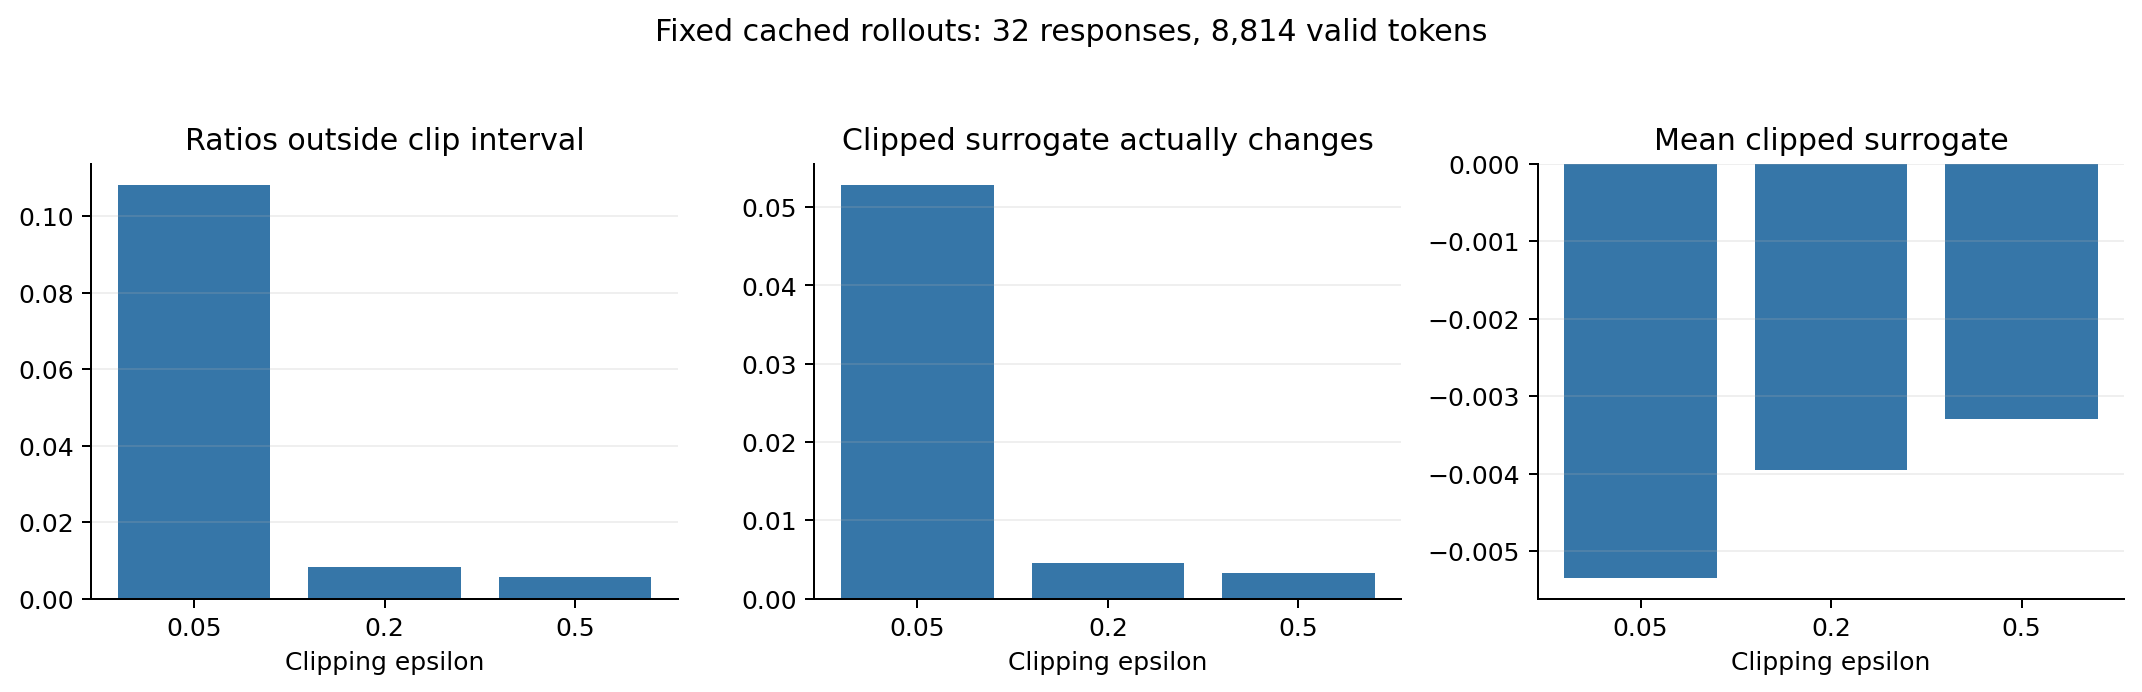

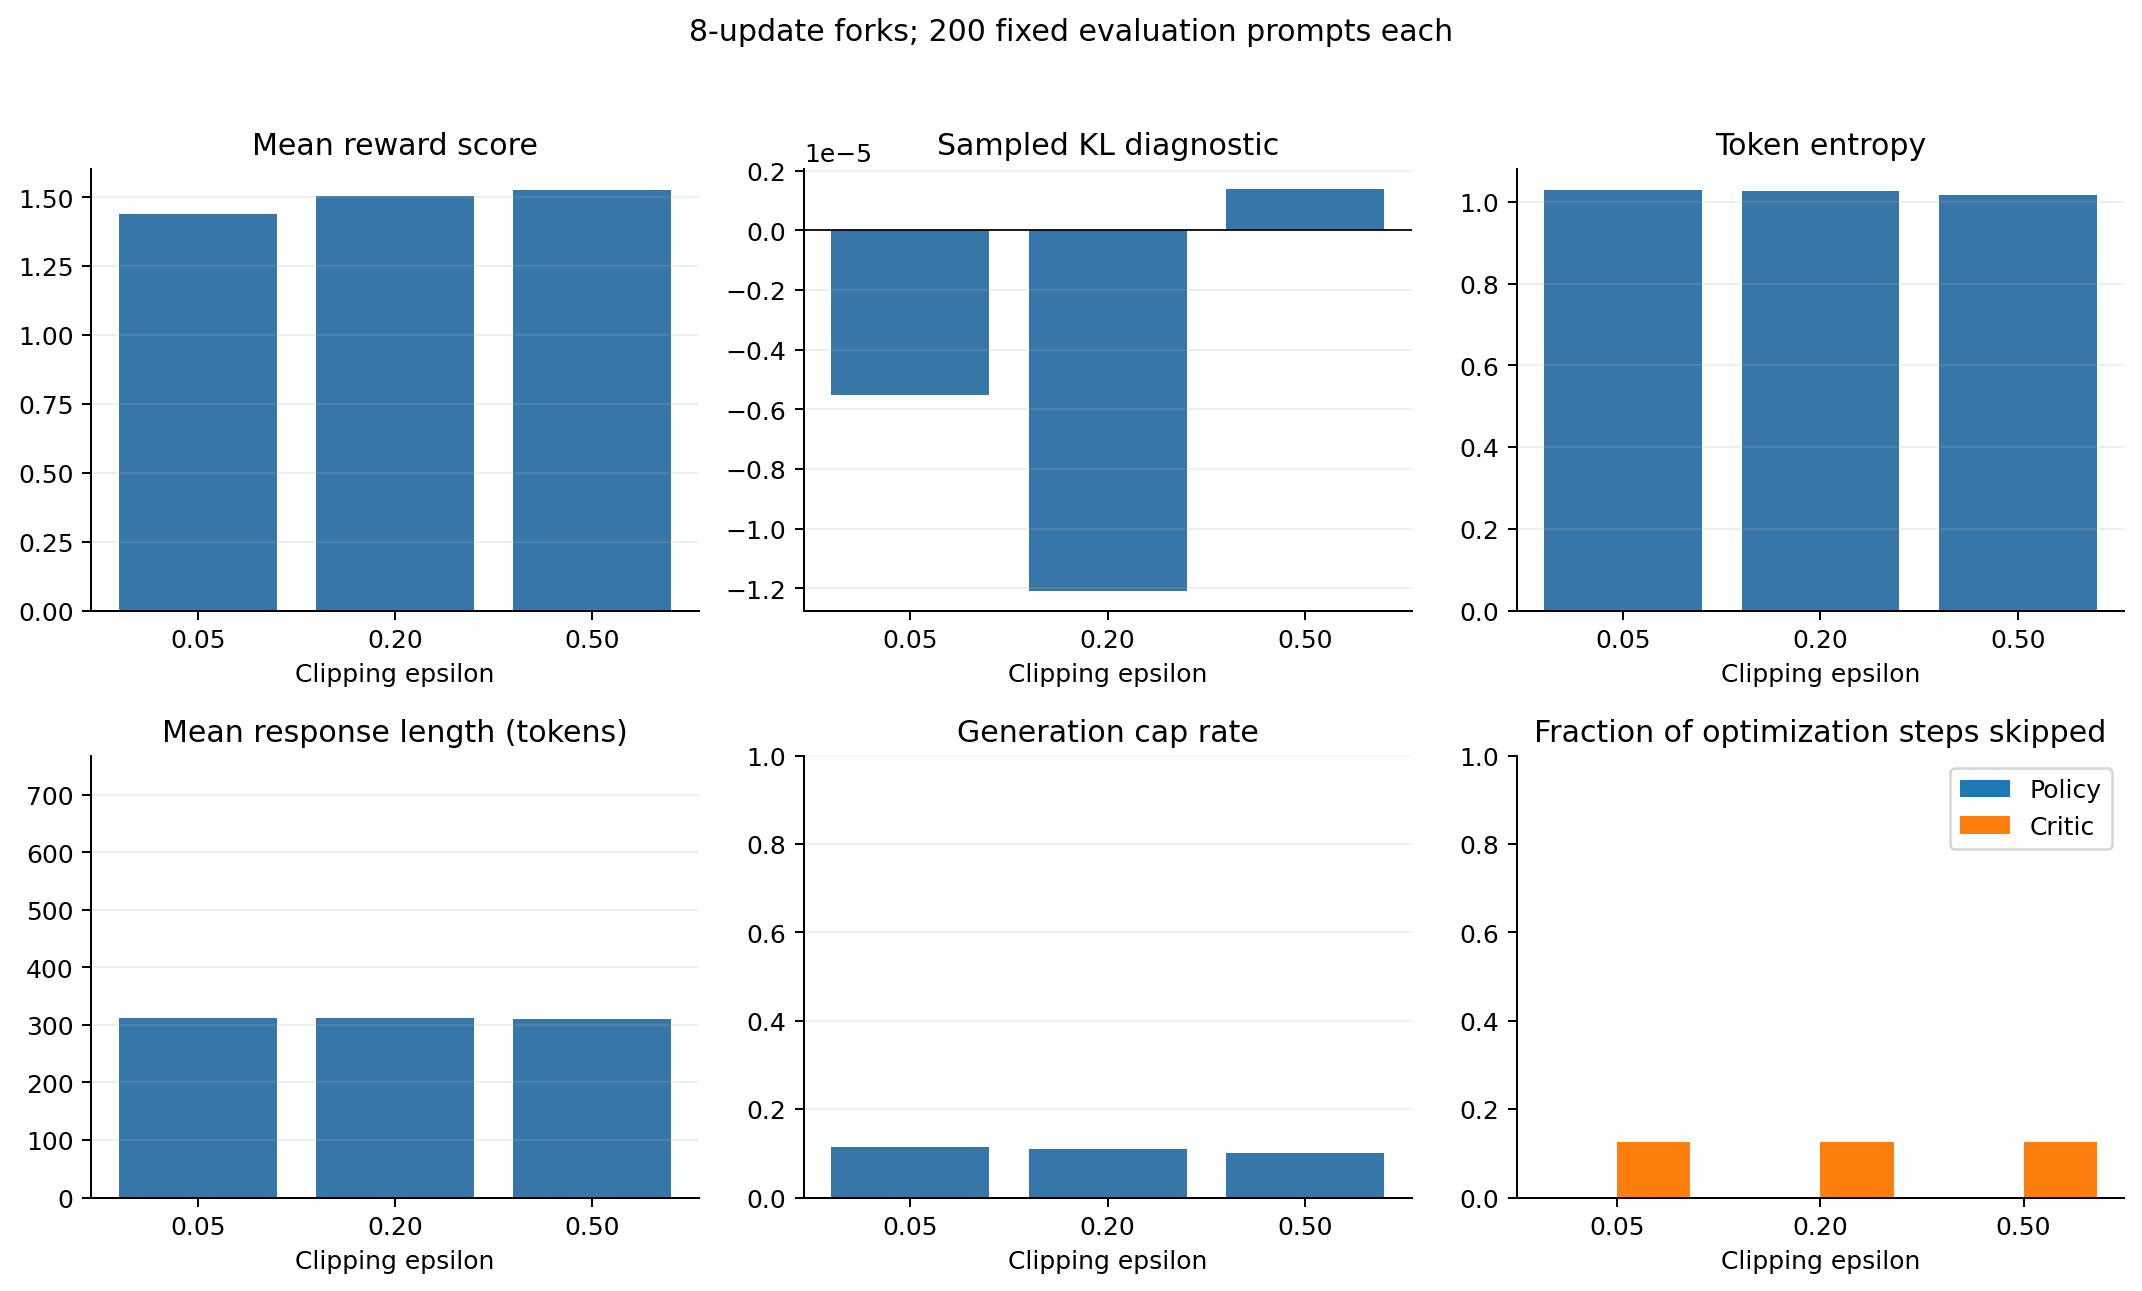

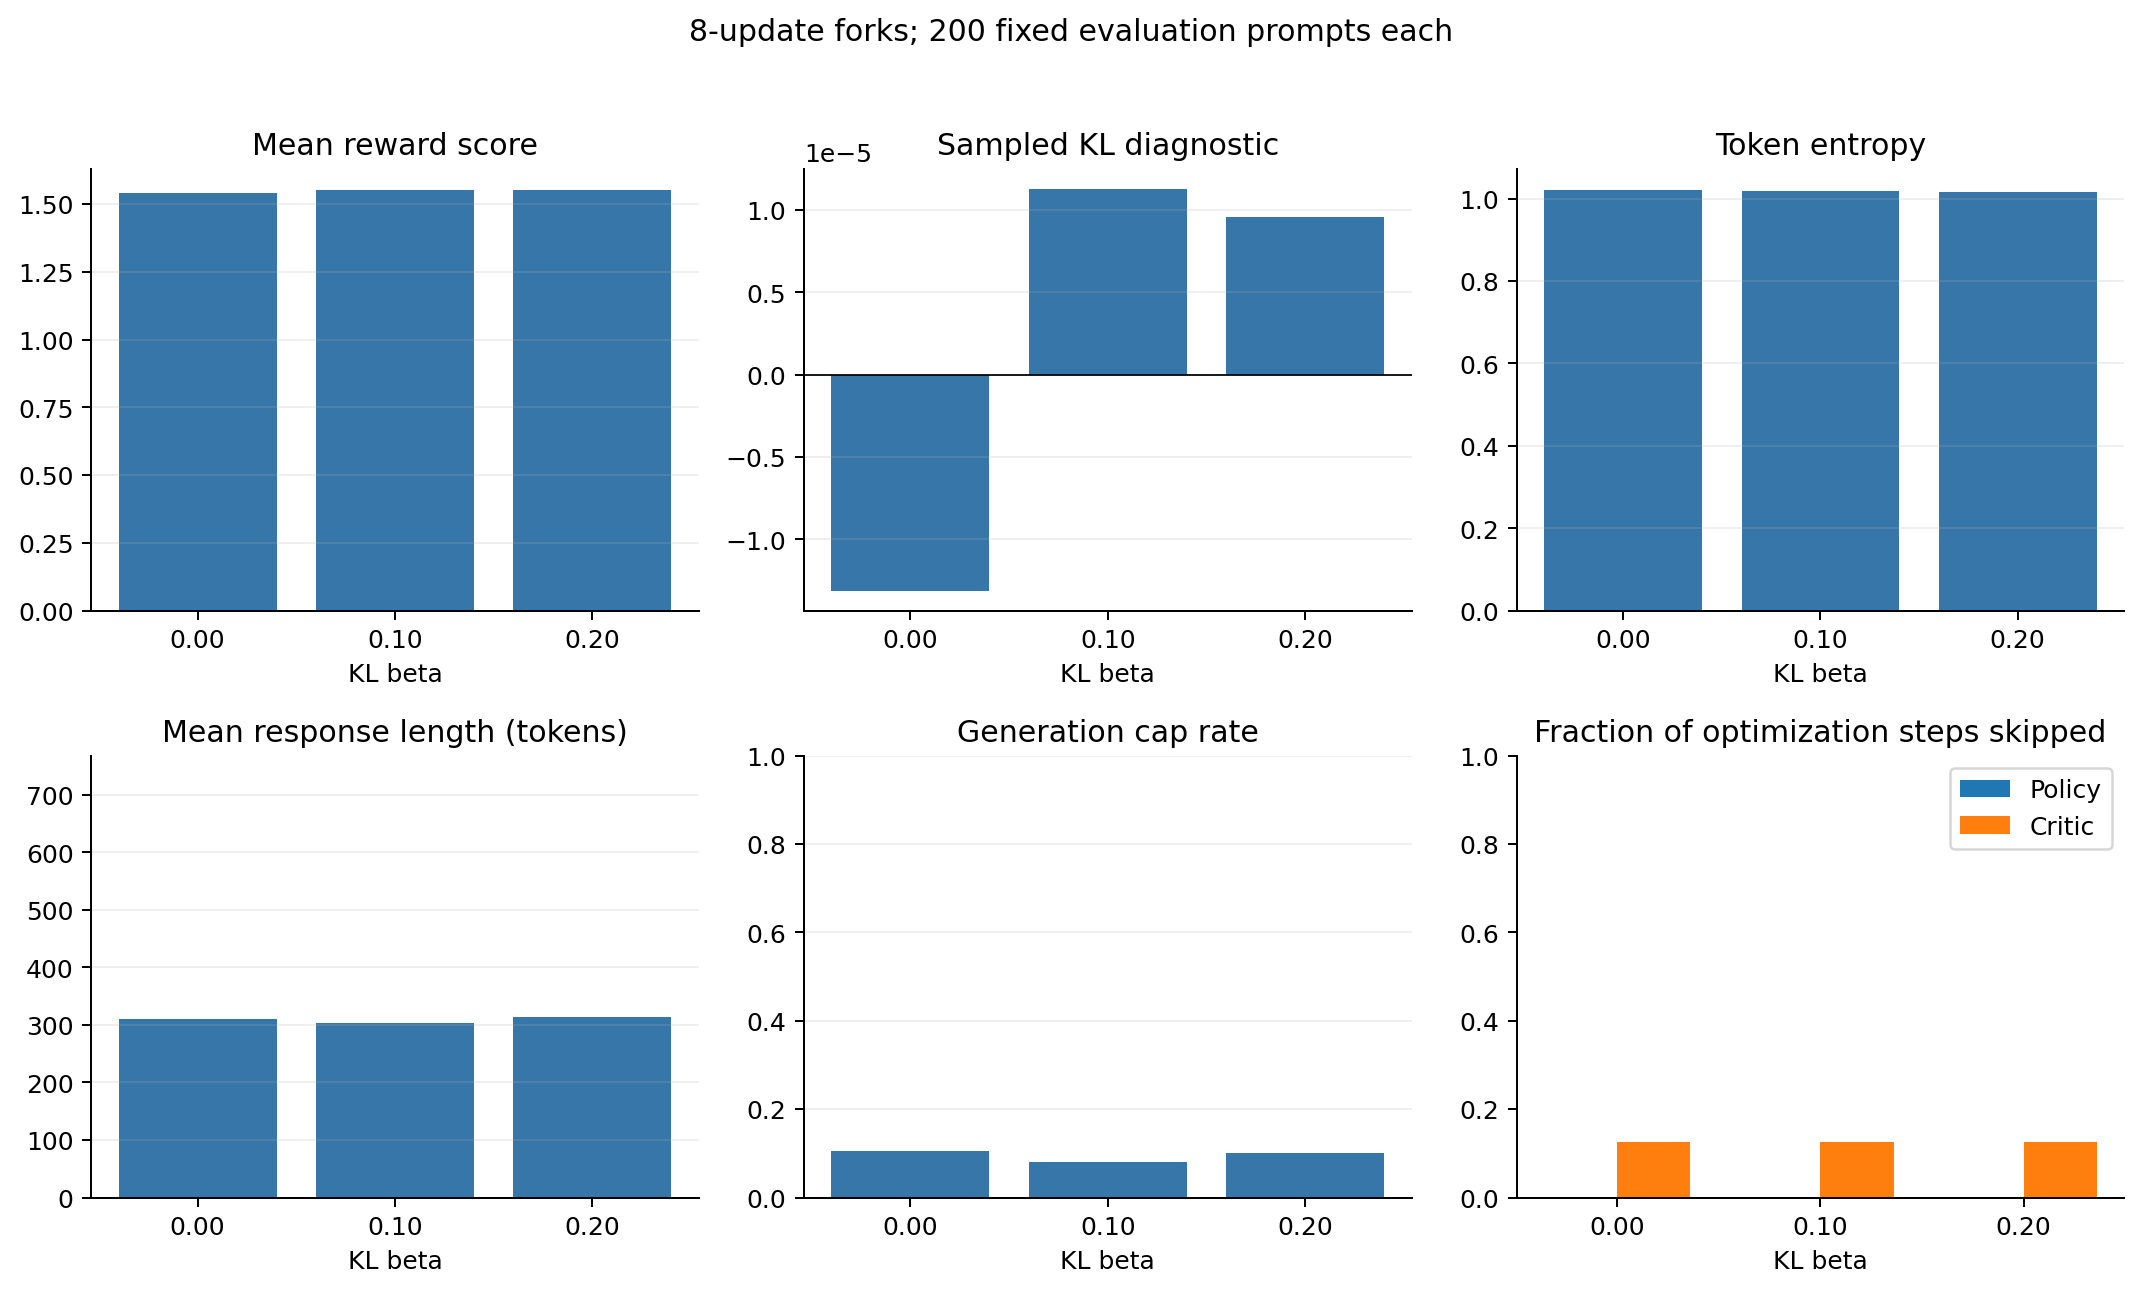

In [8]:
for name in ["task2_standard_training", "task2_cached_clipping",
             "task2_clip_comparison", "task2_kl_comparison"]:
    display(Image(filename=str(Path("report/figures") / f"{name}.png")))


In [9]:
import subprocess
from pathlib import Path

for args in [
    ["git", "status", "--short"],
    ["git", "diff", "--stat"],
    ["git", "remote", "-v"],
]:
    result = subprocess.run(
        args, capture_output=True, text=True, check=True
    )
    print(result.stdout)

print("Clean notebook locations:")
for path in Path.cwd().parent.rglob("02_PPO.ipynb"):
    print(path)

 M task2_ppo/ablate_kl.py
 M task2_ppo/analyze_clipping.py
 M task2_ppo/continue_train.py
 M task2_ppo/evaluate.py
 M task2_ppo/ppo.py
?? report/figures/task2_cached_clipping.pdf
?? report/figures/task2_cached_clipping.png
?? report/figures/task2_clip_comparison.pdf
?? report/figures/task2_clip_comparison.png
?? report/figures/task2_kl_comparison.pdf
?? report/figures/task2_kl_comparison.png
?? report/figures/task2_standard_training.pdf
?? report/figures/task2_standard_training.png
?? results/task1_dpo/smoke32_run.json
?? results/task1_dpo/smoke32_summary.json
?? results/task1_dpo/smoke32_training.jsonl
?? results/task2_ppo/
?? task2_ppo/plot_results.py
?? task2_ppo/runtime.py
?? task2_ppo/validate_objective.py

 task2_ppo/ablate_kl.py        |  29 +++--
 task2_ppo/analyze_clipping.py | 127 +++++++++++++------
 task2_ppo/continue_train.py   | 278 +++++++++++++++++++++++++++++-------------
 task2_ppo/evaluate.py         | 113 +++++++++++++----
 task2_ppo/ppo.py              |   2 +-
 5 